In [1]:
import numpy as np
from PIL import Image
from typing import List, Tuple
import matplotlib.pyplot as plt

In [2]:
def brightness_calc(R: float, G: float, B: float) -> float:
    return (0.222 * R + 0.707 * G + 0.071 * B)

In [3]:
image_name = "sk"

image_path = "origins/" + image_name + ".jpg"
image_path_save_1 = "results/" + image_name + "_binary.png"
image_path_save_2 = "results/" + image_name + "_adaptive.png"

In [21]:
block_size = 4

## Бинарное

In [4]:
image = Image.open(image_path).convert("RGB")
rgb_array = np.array(image)

brightness_array = np.zeros((rgb_array.shape[0], rgb_array.shape[1]))

for i in range(rgb_array.shape[0]):
    for j in range(rgb_array.shape[1]):
        r, g, b = rgb_array[i, j]
        brightness_array[i, j] = brightness_calc(r, g, b)

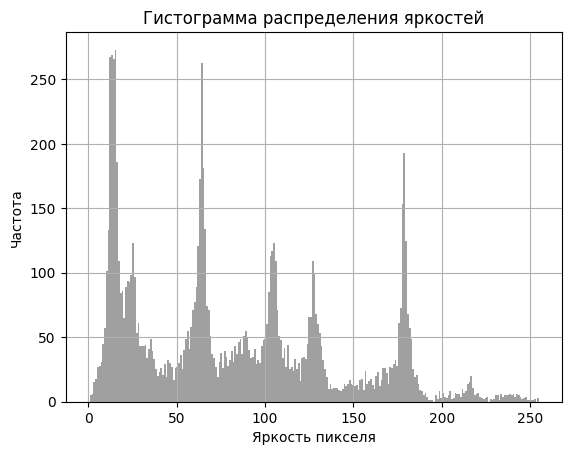

In [5]:
flatten_array = brightness_array.flatten()

plt.hist(flatten_array, bins=256, range=(0, 255), color='gray', alpha=0.75)
plt.xlabel("Яркость пикселя")
plt.ylabel("Частота")
plt.title("Гистограмма распределения яркостей")
plt.grid(True)

plt.show()

In [13]:
T = 90

In [14]:
monochrom_array = np.zeros_like(rgb_array)

for i in range(brightness_array.shape[0]):
    for j in range(brightness_array.shape[1]):
        brightness = brightness_array[i, j]

        if brightness < T:
            monochrom_array[i, j] = (0, 0, 0)
        else:
            monochrom_array[i, j] = (255, 255, 255)

Image.fromarray(monochrom_array.astype(np.uint8)).save(image_path_save_1)

## Адаптивное

In [22]:
def split_into_blocks(image: np.ndarray, block_size: int) -> List[Tuple[Tuple[int, int], np.ndarray]]:
    height, width = image.shape 
    blocks = []

    for i in range(0, height, block_size):
        for j in range(0, width, block_size):
            block = image[i:i + block_size, j:j + block_size] 
            blocks.append(((i, j), block))

    return blocks

In [16]:
def apply_threshold(image: np.ndarray, block_size: int) -> np.ndarray:
    height = len(image)
    width = len(image[0])
    result = np.zeros((height, width))
    
    blocks = split_into_blocks(image, block_size)
    
    for (start_i, start_j), block in blocks:
        threshold = np.mean(block)
        
        for i, row in enumerate(block):
            for j, pixel in enumerate(row):
                global_i = start_i + i
                global_j = start_j + j

                if global_i < height and global_j < width:
                    if pixel > threshold:
                        result[global_i][global_j] = 255
                    else:
                        result[global_i][global_j] = 0
                    
    return result

In [23]:
image = Image.open(image_path).convert("RGB")
rgb_array = np.array(image)

brightness_array = np.zeros((rgb_array.shape[0], rgb_array.shape[1]))

for i in range(rgb_array.shape[0]):
    for j in range(rgb_array.shape[1]):
        r, g, b = rgb_array[i, j]
        brightness_array[i, j] = brightness_calc(r, g, b)

In [24]:
monochrom_array = apply_threshold(brightness_array, block_size)

Image.fromarray(monochrom_array.astype(np.uint8)).save(image_path_save_2)